# 🫀 Notebook 2 — Clustering y Análisis de Fenotipos
## Identificación de Fenotipos de Pacientes con Insuficiencia Cardíaca
**Proyecto Curso I — Especialización Machine Learning Engineering**  
Ramos Miranda, Jaime

---
Este notebook cubre la determinación del número óptimo de clusters, el modelo K-Means,
la caracterización de fenotipos y la validación clínica externa.  
**Requiere haber ejecutado primero `01_preprocesamiento.ipynb`.**

## 1. Librerías

In [ ]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

In [ ]:
Datos = pd.read_csv("../data/datos_estandarizados.csv")
Datos0 = pd.read_csv("../data/datos_originales_limpios.csv")
target = pd.read_csv("../data/target.csv").squeeze()

print(f"Datos para clustering: {Datos.shape}")
print(f"Pacientes: {len(Datos)}, Variables: {len(Datos.columns)}")
Datos.head()

Datos para clustering: (283, 12)
Pacientes: 283, Variables: 12


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,0.016816,0.490057,-1.504036,0.735688,-0.687682,-1.629502
1,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073,-0.090900,-1.731046,0.735688,1.454161,-1.590785
2,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-0.546474,0.490057,0.085034,0.735688,-0.687682,-1.590785
3,2.456114,1.147968,-0.552141,-0.847579,0.162199,1.359272,-0.607924,0.683709,-1.050016,0.735688,1.454161,-1.577879
4,1.192945,1.147968,-0.346704,-0.847579,-1.953749,-0.735688,-1.396531,-0.187726,0.085034,0.735688,-0.687682,-1.552067


## 3. Matriz de distancias euclidianas

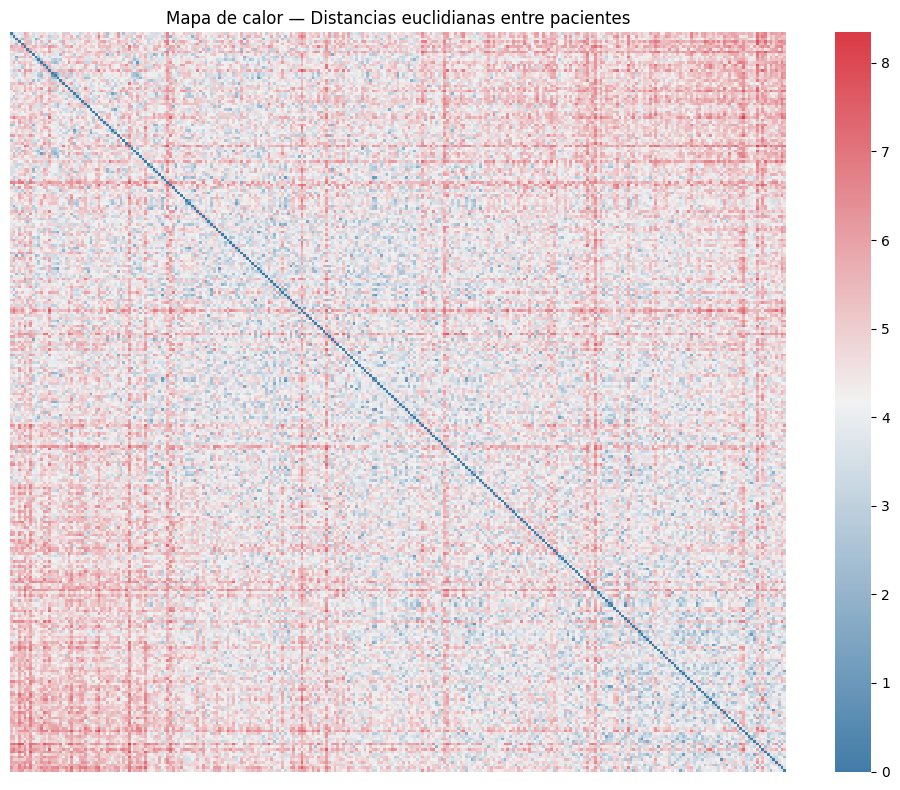

In [ ]:
dist_matrix = squareform(pdist(Datos, metric="euclidean"))

plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix,
            cmap=sns.diverging_palette(240, 10, as_cmap=True),
            xticklabels=False, yticklabels=False)
plt.title("Mapa de calor — Distancias euclidianas entre pacientes")
plt.tight_layout()
plt.savefig("../artifacts/distancias_euclideas.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Clustering jerárquico exploratorio

Se usa el método Ward para explorar la estructura jerárquica de los datos antes de decidir el número de clusters.

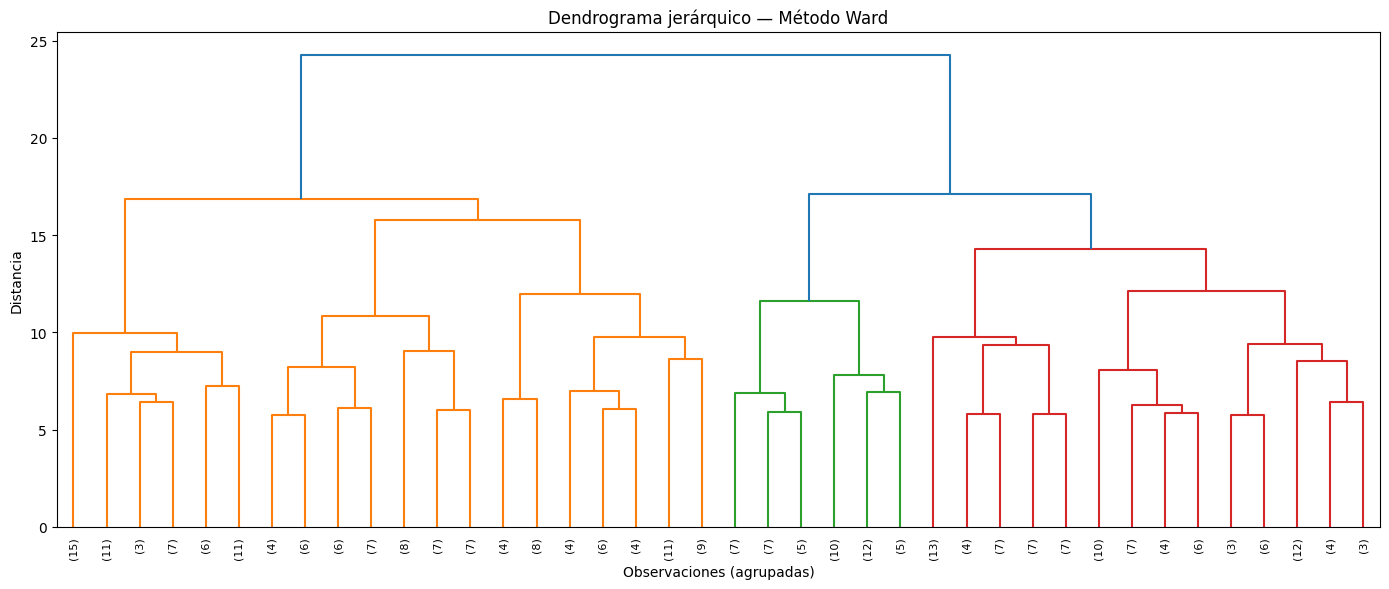

In [ ]:
linkage_matrix = linkage(Datos, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=40,
           leaf_rotation=90, leaf_font_size=8, color_threshold=None)
plt.title("Dendrograma jerárquico — Método Ward")
plt.xlabel("Observaciones (agrupadas)")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig("../artifacts/dendrograma_exploratorio.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Determinación del número óptimo de clusters

### 5a. Método de la Silueta

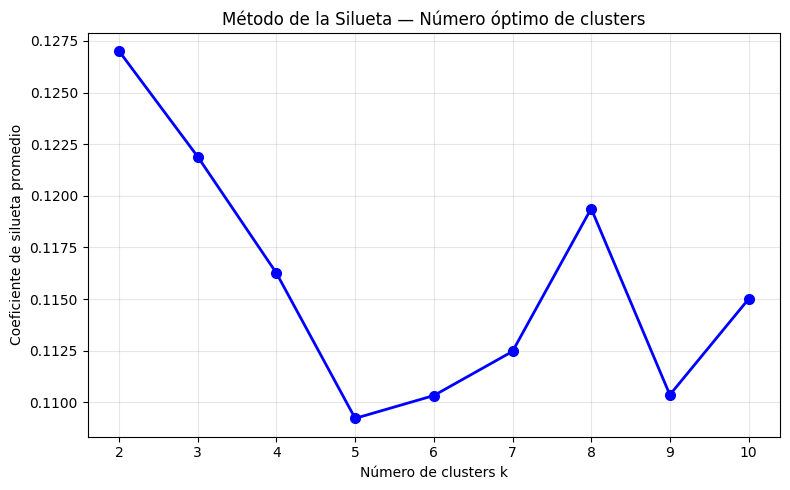

Coeficientes de silueta por k:
  k=2: 0.1270
  k=3: 0.1219
  k=4: 0.1163
  k=5: 0.1092
  k=6: 0.1103
  k=7: 0.1125
  k=8: 0.1194
  k=9: 0.1104
  k=10: 0.1150

→ k óptimo por silueta: 2


In [ ]:
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=2020)
    labels = km.fit_predict(Datos)
    sil_scores.append(silhouette_score(Datos, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), sil_scores, "bo-", linewidth=2, markersize=7)
plt.xlabel("Número de clusters k")
plt.ylabel("Coeficiente de silueta promedio")
plt.title("Método de la Silueta — Número óptimo de clusters")
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/metodo_silueta.png", dpi=150, bbox_inches="tight")
plt.show()

print("Coeficientes de silueta por k:")
for k, s in zip(K_range, sil_scores):
    print(f"  k={k}: {s:.4f}")
k_sil = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"\n→ k óptimo por silueta: {k_sil}")

### 5b. Método del Codo (WSS)

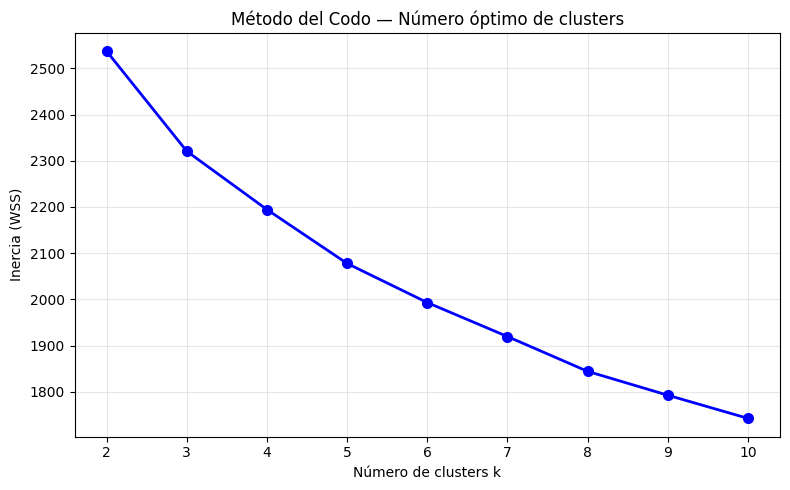

In [ ]:
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=2020)
    km.fit(Datos)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, "bo-", linewidth=2, markersize=7)
plt.xlabel("Número de clusters k")
plt.ylabel("Inercia (WSS)")
plt.title("Método del Codo — Número óptimo de clusters")
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/metodo_codo.png", dpi=150, bbox_inches="tight")
plt.show()

### 5c. Gap Statistic

Calculando Gap Statistic...


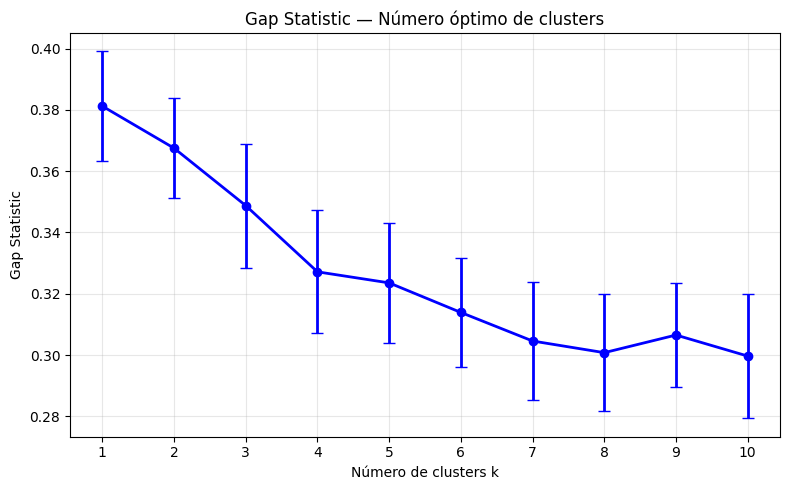

In [ ]:
def gap_statistic(data, k_max=10, n_boot=100, random_state=2020):
    """
    Calcula el estadístico Gap para determinar el número óptimo de clusters.

    Parameters
    ----------
    data : pd.DataFrame
        Datos estandarizados.
    k_max : int
        Número máximo de clusters a evaluar.
    n_boot : int
        Muestras bootstrap para la referencia aleatoria.
    random_state : int
        Semilla para reproducibilidad.

    Returns
    -------
    gaps : np.ndarray
        Valores Gap por k.
    gap_std : np.ndarray
        Desviaciones estándar ajustadas.
    """
    rng = np.random.default_rng(random_state)
    gaps, gap_std = [], []
    data_arr = data.values if hasattr(data, "values") else data
    mins, maxs = data_arr.min(axis=0), data_arr.max(axis=0)

    for k in range(1, k_max + 1):
        km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=random_state)
        km.fit(data_arr)
        Wk = np.log(km.inertia_)
        boot_Wks = []
        for _ in range(n_boot):
            rand_data = rng.uniform(mins, maxs, size=data_arr.shape)
            km_b = KMeans(n_clusters=k, n_init=5, max_iter=100, random_state=random_state)
            km_b.fit(rand_data)
            boot_Wks.append(np.log(km_b.inertia_))
        gaps.append(np.mean(boot_Wks) - Wk)
        gap_std.append(np.std(boot_Wks) * np.sqrt(1 + 1/n_boot))

    return np.array(gaps), np.array(gap_std)

print("Calculando Gap Statistic...")
gaps, gap_sds = gap_statistic(Datos, k_max=10, n_boot=100)

plt.figure(figsize=(8, 5))
plt.errorbar(range(1, 11), gaps, yerr=gap_sds, fmt="bo-", capsize=4, linewidth=2)
plt.xlabel("Número de clusters k")
plt.ylabel("Gap Statistic")
plt.title("Gap Statistic — Número óptimo de clusters")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/gap_statistic.png", dpi=150, bbox_inches="tight")
plt.show()

### 5d. Decisión del número de clusters

| Método | k sugerido |
|---|---|
| Silueta | k=2 (máximo estadístico) |
| Codo (WSS) | k=3–4 (punto de inflexión) |
| Gap Statistic | k=3–4 |
| **Criterio clínico** | **k=4** |

**Justificación de k=4:** aunque k=2 maximiza la silueta, los fenotipos resultantes son casi indistinguibles en mortalidad (31.3% vs 28.7%). Con k=4 emerge un fenotipo de altísimo riesgo (73.3% mortalidad) clínicamente muy relevante.

## 6. K-Means con k=4 (modelo principal)

In [ ]:
k_final = 4

km_final = KMeans(n_clusters=k_final, n_init=20, max_iter=300, random_state=2020)
km_final.fit(Datos)

print(f"=== K-Means k={k_final} ===")
print(f"Inercia (WSS):          {km_final.inertia_:.2f}")
print(f"Silueta:                {silhouette_score(Datos, km_final.labels_):.4f}")
print(f"Davies-Bouldin:         {davies_bouldin_score(Datos, km_final.labels_):.4f}")
print(f"Calinski-Harabasz:      {calinski_harabasz_score(Datos, km_final.labels_):.2f}")
print(f"\nDistribución de clusters:")
print(pd.Series(km_final.labels_ + 1).value_counts().sort_index())

=== K-Means k=4 ===
Inercia (WSS):          2194.36
Silueta:                0.1163
Davies-Bouldin:         2.3085
Calinski-Harabasz:      29.79

Distribución de clusters:
1    69
2    79
3    90
4    45
Name: count, dtype: int64


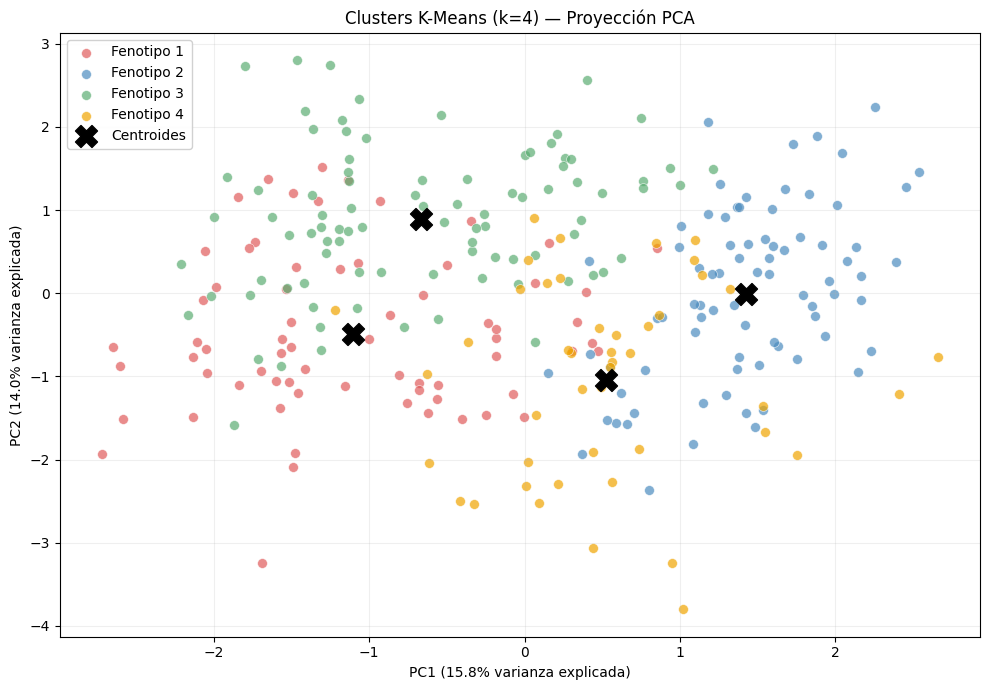

Varianza total explicada por 2 PCs: 29.8%


In [ ]:
# Visualización con PCA
pca = PCA(n_components=2, random_state=2020)
Datos_pca = pca.fit_transform(Datos)
var_exp = pca.explained_variance_ratio_

colores = ["#E05C5C", "#4C8CBF", "#5BAD72", "#F0A500"]
labels_pca = km_final.labels_

plt.figure(figsize=(10, 7))
for i, c in enumerate(colores):
    mask = labels_pca == i
    plt.scatter(Datos_pca[mask, 0], Datos_pca[mask, 1],
                color=c, label=f"Fenotipo {i+1}", alpha=0.7, s=50, edgecolors="white", linewidth=0.5)

centroides_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            color="black", marker="X", s=250, zorder=5, label="Centroides")

plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza explicada)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza explicada)")
plt.title(f"Clusters K-Means (k={k_final}) — Proyección PCA")
plt.legend(framealpha=0.9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../artifacts/clusters_kmeans_k4.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Varianza total explicada por 2 PCs: {sum(var_exp)*100:.1f}%")

## 7. Clustering jerárquico confirmatorio (k=4)

Distribución clusters jerárquicos k=4: {1: 53, 2: 91, 3: 46, 4: 93}


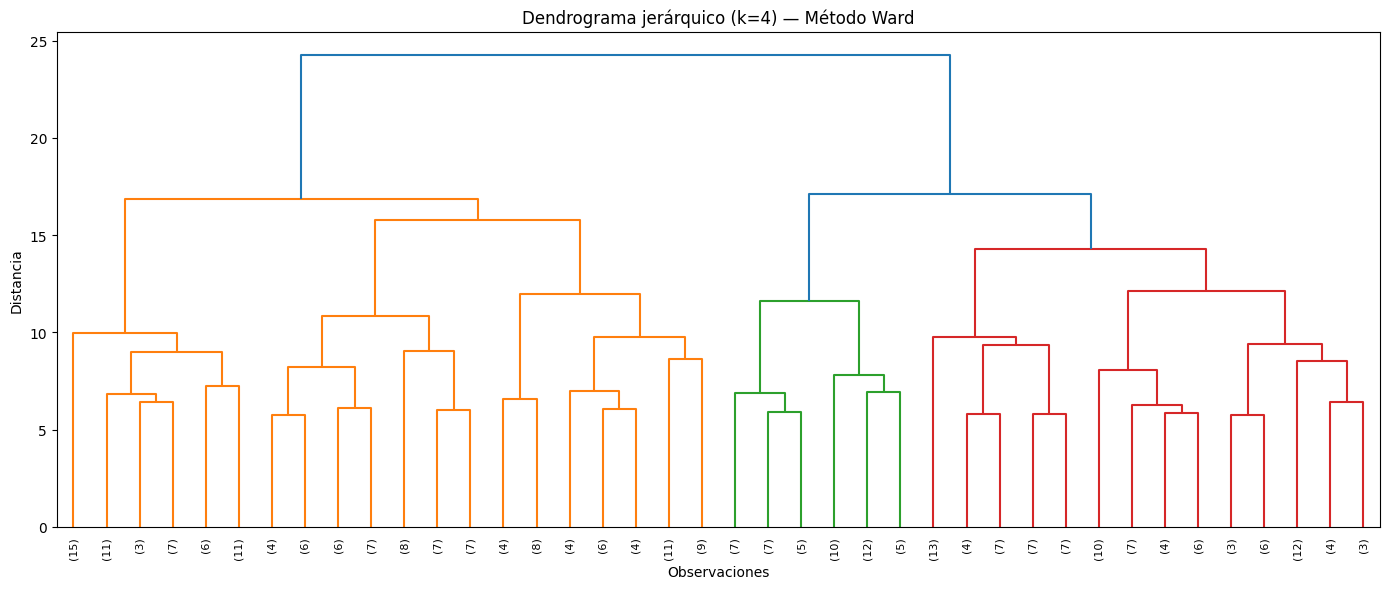

In [ ]:
hier_labels = fcluster(linkage_matrix, t=k_final, criterion="maxclust")
print(f"Distribución clusters jerárquicos k={k_final}:",
      pd.Series(hier_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=40,
           leaf_rotation=90, leaf_font_size=8, color_threshold=None)
plt.title(f"Dendrograma jerárquico (k={k_final}) — Método Ward")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.savefig("../artifacts/dendrograma_k4.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Asignación de fenotipos

In [ ]:
fenotipo = km_final.labels_ + 1  # 1-based
Datos3 = Datos0.copy()
Datos3["fenotipo"] = fenotipo
Datos3["DEATH_EVENT"] = target.values

print("Shape de Datos3:", Datos3.shape)
print("\nDistribución de fenotipos:")
print(Datos3["fenotipo"].value_counts().sort_index())

Shape de Datos3: (283, 14)

Distribución de fenotipos:
fenotipo
1    69
2    79
3    90
4    45
Name: count, dtype: int64


## 9. Perfiles de fenotipos

In [ ]:
cols_continuas = ["age", "creatinine_phosphokinase", "ejection_fraction",
                  "platelets", "serum_creatinine", "serum_sodium", "time"]

print("=== Medias de variables continuas por fenotipo ===")
perfil_cont = Datos3.groupby("fenotipo")[cols_continuas].mean().round(2)
print(perfil_cont.to_string())

=== Medias de variables continuas por fenotipo ===
            age  creatinine_phosphokinase  ejection_fraction  platelets  serum_creatinine  serum_sodium    time
fenotipo                                                                                                       
1         60.46                    438.91              39.17  268881.02              1.11        136.99  117.09
2         59.67                    469.04              37.71  260512.74              1.17        137.38  142.65
3         56.92                    528.86              40.66  265005.91              1.18        137.80  161.74
4         71.69                    390.02              31.07  229136.63              1.99        133.58   81.47


In [ ]:
cols_binarias = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

print("=== % de pacientes con la condición por fenotipo ===")
perfil_bin = (Datos3.groupby("fenotipo")[cols_binarias].mean() * 100).round(1)
print(perfil_bin.to_string())

=== % de pacientes con la condición por fenotipo ===
          anaemia  diabetes  high_blood_pressure    sex  smoking
fenotipo                                                        
1            46.4      44.9                100.0   39.1      2.9
2            35.4      31.6                 29.1  100.0    100.0
3            45.6      55.6                  0.0   42.2      0.0
4            46.7      24.4                 20.0   88.9     17.8


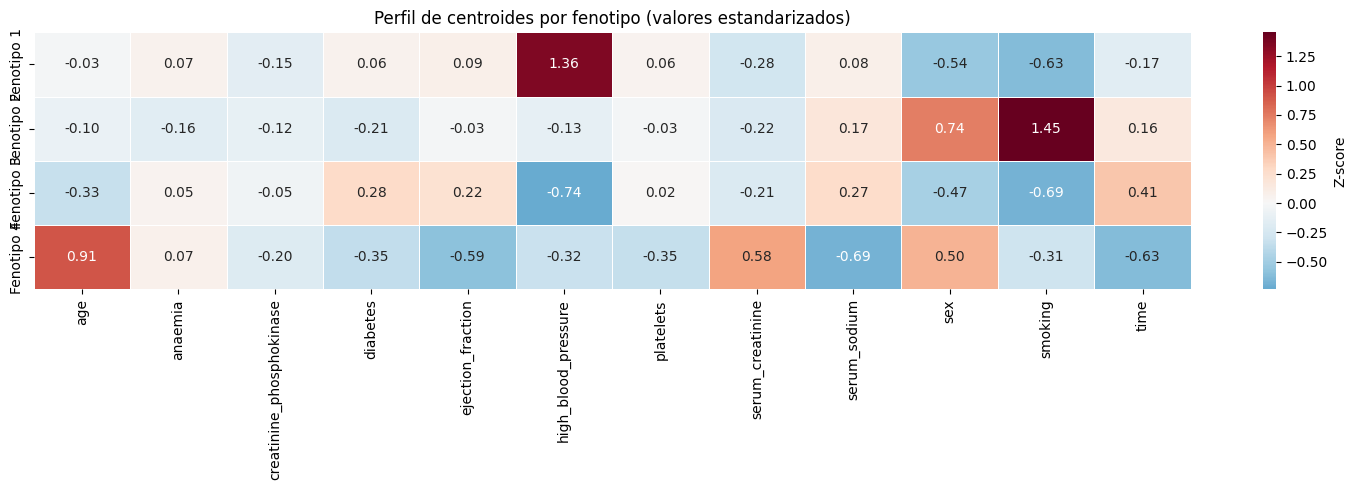

In [ ]:
# Heatmap de centroides estandarizados
centroides_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=Datos.columns,
    index=[f"Fenotipo {i+1}" for i in range(k_final)]
)

plt.figure(figsize=(15, 5))
sns.heatmap(centroides_df, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5,
            cbar_kws={"label": "Z-score"})
plt.title("Perfil de centroides por fenotipo (valores estandarizados)")
plt.tight_layout()
plt.savefig("../artifacts/perfiles_centroides.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Validación clínica externa — Mortalidad por fenotipo

=== Tasa de mortalidad por fenotipo ===
          fallecidos  total  tasa_mortalidad_%
fenotipo                                      
1                 19     69               27.5
2                 19     79               24.1
3                 15     90               16.7
4                 33     45               73.3


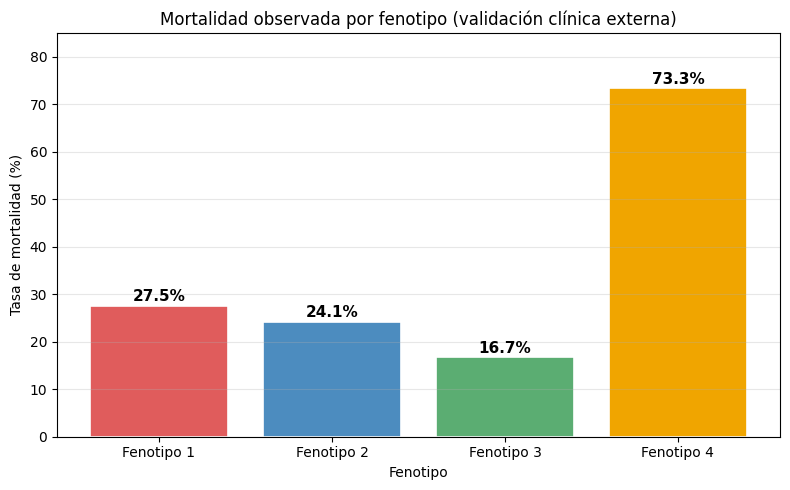

In [ ]:
mort = Datos3.groupby("fenotipo")["DEATH_EVENT"].agg(["sum","count"])
mort.columns = ["fallecidos", "total"]
mort["tasa_mortalidad_%"] = (mort["fallecidos"] / mort["total"] * 100).round(1)

print("=== Tasa de mortalidad por fenotipo ===")
print(mort)

plt.figure(figsize=(8, 5))
bars = plt.bar([f"Fenotipo {i}" for i in mort.index],
               mort["tasa_mortalidad_%"],
               color=colores, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, mort["tasa_mortalidad_%"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val}%", ha="center", fontsize=11, fontweight="bold")

plt.xlabel("Fenotipo")
plt.ylabel("Tasa de mortalidad (%)")
plt.title("Mortalidad observada por fenotipo (validación clínica externa)")
plt.ylim(0, 85)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../artifacts/mortalidad_por_fenotipo.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Exportar resultados

In [ ]:
# Dataset con fenotipos asignados
Datos3.to_csv("../artifacts/heart_failure_con_fenotipos.csv", index=False)
print("heart_failure_con_fenotipos.csv exportado.")

# Recalcular perfiles por si se ejecuta esta celda de forma aislada
cols_continuas = ["age", "creatinine_phosphokinase", "ejection_fraction",
                  "platelets", "serum_creatinine", "serum_sodium", "time"]
cols_binarias = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

perfil_cont = Datos3.groupby("fenotipo")[cols_continuas].mean().round(2)
perfil_bin  = (Datos3.groupby("fenotipo")[cols_binarias].mean() * 100).round(1)

centroides_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=Datos.columns,
    index=[f"Fenotipo {i+1}" for i in range(k_final)]
)

mort = Datos3.groupby("fenotipo")["DEATH_EVENT"].agg(["sum", "count"])
mort.columns = ["fallecidos", "total"]
mort["tasa_mortalidad_%"] = (mort["fallecidos"] / mort["total"] * 100).round(1)

# Etiquetas legibles para tablas categóricas
Datos4 = Datos3.copy()
Datos4["sex"]                = Datos4["sex"].map({0: "mujer", 1: "hombre"})
Datos4["anaemia"]            = Datos4["anaemia"].map({0: "no", 1: "sí"})
Datos4["diabetes"]           = Datos4["diabetes"].map({0: "no", 1: "sí"})
Datos4["high_blood_pressure"]= Datos4["high_blood_pressure"].map({0: "no", 1: "sí"})
Datos4["smoking"]            = Datos4["smoking"].map({0: "no", 1: "sí"})
Datos4["DEATH_EVENT"]        = Datos4["DEATH_EVENT"].map({0: "vivo", 1: "fallecido"})

with pd.ExcelWriter("../artifacts/cuadros_fenotipos.xlsx", engine="openpyxl") as writer:
    perfil_cont.to_excel(writer, sheet_name="Variables continuas")
    perfil_bin.to_excel(writer, sheet_name="Variables binarias pct")
    mort.to_excel(writer, sheet_name="Mortalidad")
    centroides_df.to_excel(writer, sheet_name="Centroides")
    Datos4.groupby(["fenotipo", "sex"]).size().reset_index(name="Freq").to_excel(writer, sheet_name="Sexo", index=False)
    Datos4.groupby(["fenotipo", "anaemia"]).size().reset_index(name="Freq").to_excel(writer, sheet_name="Anemia", index=False)
    Datos4.groupby(["fenotipo", "diabetes"]).size().reset_index(name="Freq").to_excel(writer, sheet_name="Diabetes", index=False)
    Datos4.groupby(["fenotipo", "high_blood_pressure"]).size().reset_index(name="Freq").to_excel(writer, sheet_name="Hipertension", index=False)
    Datos4.groupby(["fenotipo", "smoking"]).size().reset_index(name="Freq").to_excel(writer, sheet_name="Tabaquismo", index=False)

print("cuadros_fenotipos.xlsx exportado.")

heart_failure_con_fenotipos.csv exportado.
cuadros_fenotipos.xlsx exportado.


---
## ✅ Resumen de resultados

| Métrica | Valor |
|---|---|
| Algoritmo | K-Means (k=4) |
| Silueta | 0.1163 |
| Davies-Bouldin | 2.3085 |
| Calinski-Harabasz | 29.79 |
| Inercia (WSS) | 2194.36 |

| Fenotipo | N | Mortalidad | Perfil clave |
|---|---|---|---|
| F1 | 69 | 27.5% | 100% hipertensión, mayoría mujeres |
| F2 | 79 | 24.1% | 100% masculino, 100% fumador |
| F3 | 90 | 16.7% | Más jóvenes, mejor función cardíaca |
| F4 | 45 | **73.3%** | Mayor edad, creatinina alta, sodio bajo ⚠️ |